In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ALLFLOWMETER_HIKARI2021.csv')

In [ ]:
df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis = 1, inplace=True)

In [ ]:
df_exclude_object = df.select_dtypes(exclude=['object'])

In [ ]:
X = df_exclude_object.iloc[:,:-1]
y = df_exclude_object.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Naive Bayes Gaussian Classifier


In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Build a Gaussian Classifier
nbgc = GaussianNB()

In [ ]:
# Model training
nbgc.fit(X_train, y_train)

# Predict Output
pred_nbgc = nbgc.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
print(classification_report(y_test, pred_nbgc))

              precision    recall  f1-score   support

           0       0.99      0.26      0.41    155295
           1       0.09      0.98      0.16     11289

    accuracy                           0.31    166584
   macro avg       0.54      0.62      0.28    166584
weighted avg       0.93      0.31      0.39    166584



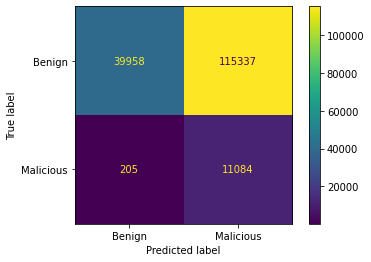

In [ ]:
labels = ["Benign", "Malicious"]
cm = confusion_matrix(y_test, pred_nbgc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="viridis", values_format='');